In [17]:
import sys
from pathlib import Path
import importlib.util

# 1. Forzar la raíz del proyecto hacia la carpeta principal
# Busca la carpeta que contiene 'src' y 'utils' subiendo en el árbol de directorios
notebook_path = Path('.').resolve()
PROJECT_ROOT = next((p for p in [notebook_path] + list(notebook_path.parents) if (p / 'src').exists()), notebook_path.parent)

# 2. Agregar la raíz al sys.path si no está ya
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print(f"✅ Entorno configurado correctamente.")
print(f"📍 Ruta Raíz Detectada: {PROJECT_ROOT}")

✅ Entorno configurado correctamente.
📍 Ruta Raíz Detectada: /workspaces/logistica-pro-analysis


In [18]:
import sys
from pathlib import Path
import importlib.util

# 1. Registrar la raíz en el path
PROJECT_ROOT = Path('/workspaces/logistica-pro-analysis')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 2. Cargar el script
ruta_script = PROJECT_ROOT / 'src' / '01_carga_datos' / 'cargar_excel.py'
spec = importlib.util.spec_from_file_location("cargar_excel", ruta_script)
mod_carga = importlib.util.module_from_spec(spec)
sys.modules["cargar_excel"] = mod_carga
spec.loader.exec_module(mod_carga)

# 3. Cargar datos
hojas = mod_carga.cargar_hojas_excel()

print(f"📁 Hojas cargadas: {list(hojas.keys())}")

📁 Archivo Excel encontrado de forma dinámica: logistica_pro_expandido (2).xlsx
2026-07-21 21:35:26 | INFO     | logistica_pro | Cargando archivo: /workspaces/logistica-pro-analysis/data/raw/logistica_pro_expandido (2).xlsx
2026-07-21 21:35:26 | INFO     | logistica_pro |   → Cargando hoja: Productos
2026-07-21 21:35:27 | INFO     | logistica_pro |     ✓ 200 filas, 24 columnas
2026-07-21 21:35:27 | INFO     | logistica_pro |   → Cargando hoja: Proveedores
2026-07-21 21:35:27 | INFO     | logistica_pro |     ✓ 50 filas, 18 columnas
2026-07-21 21:35:27 | INFO     | logistica_pro |   → Cargando hoja: Clientes
2026-07-21 21:35:27 | INFO     | logistica_pro |     ✓ 100 filas, 19 columnas
2026-07-21 21:35:27 | INFO     | logistica_pro |   → Cargando hoja: Almacenes
2026-07-21 21:35:27 | INFO     | logistica_pro |     ✓ 10 filas, 16 columnas
2026-07-21 21:35:27 | INFO     | logistica_pro |   → Cargando hoja: Transporte
2026-07-21 21:35:27 | INFO     | logistica_pro |     ✓ 25 filas, 16 columna

In [19]:
nombre_hoja = 'Productos'
df = hojas[nombre_hoja].copy()

if df.iloc[0].astype(str).equals(df.columns.astype(str)):
    df = df.iloc[1:].reset_index(drop=True)

print(f"=== {nombre_hoja} ===")
print(f"Filas: {len(df)}")
print(f"Columnas: {list(df.columns)}")
df.head()

=== Productos ===
Filas: 200
Columnas: ['SKU', 'Nombre', 'Categoría', 'Subcategoría', 'Marca', 'Modelo', 'Gama', 'Costo USD', 'Precio USD', 'Margen %', 'Peso kg', 'Volumen m3', 'Origen', 'Proveedor', 'Stock Min', 'Stock Máx', 'Punto Reorden', 'Estado', 'Condición', 'Garantía Meses', 'Año Lanzamiento', 'Certificación', 'Código Barras', 'Descripción']


,SKU,Nombre,Categoría,Subcategoría,Marca,Modelo,Gama,Costo USD,Precio USD,Margen %,...,Stock Min,Stock Máx,Punto Reorden,Estado,Condición,Garantía Meses,Año Lanzamiento,Certificación,Código Barras,Descripción
0,SKU-0001,Crucial GPU Model-130,GPU,General,Crucial,M1409,Alta,160.20,221.30,38.1,...,18,198,90,Activo,Reacondicionado,12,2025,UL,7502801823908,"Producto Crucial GPU modelo M1409, gama alta"
1,SKU-0002,Samsung Peripherals Model-444,Peripherals,General,Samsung,M5557,Baja,391.46,551.00,40.8,...,11,154,33,En revisión,Nuevo,36,2025,ENERGY STAR,7504466589567,"Producto Samsung Peripherals modelo M5557, gam..."
2,SKU-0003,Western Digital Cooling Model-171,Cooling,General,Western Digital,M9785,Baja,487.90,825.57,69.2,...,11,121,44,Descontinuado,Nuevo,24,2021,TÜV,7506488854841,"Producto Western Digital Cooling modelo M9785,..."
3,SKU-0004,Crucial Motherboard Model-646,Motherboard,General,Crucial,M3664,Alta,209.87,434.69,107.1,...,25,250,100,Activo,Nuevo,36,2026,UL,7508235363119,"Producto Crucial Motherboard modelo M3664, gam..."
4,SKU-0005,EVGA CPU Model-505,CPU,General,EVGA,M4752,Baja,412.27,709.73,72.2,...,25,450,100,Activo,Nuevo,36,2022,UL,7507609857128,"Producto EVGA CPU modelo M4752, gama baja"


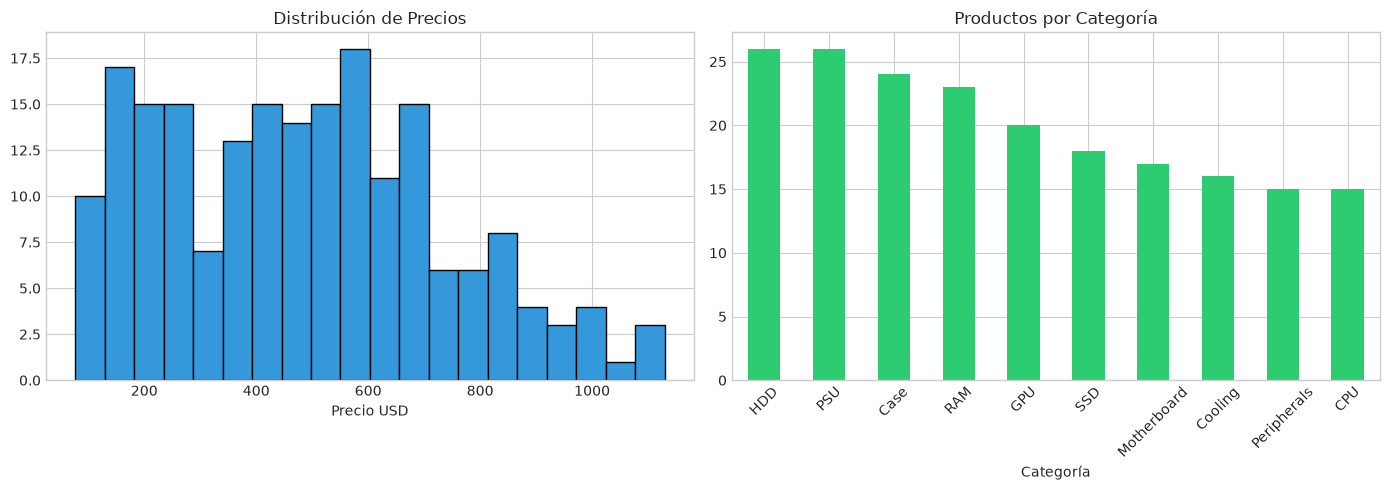

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'Precio USD' in df.columns:
    df['Precio USD'] = pd.to_numeric(df['Precio USD'], errors='coerce')
    df['Precio USD'].hist(bins=20, ax=axes[0], color='#3498db', edgecolor='black')
    axes[0].set_title('Distribución de Precios')
    axes[0].set_xlabel('Precio USD')

if 'Categoría' in df.columns:
    cat_counts = df['Categoría'].value_counts()
    cat_counts.plot(kind='bar', ax=axes[1], color='#2ecc71')
    axes[1].set_title('Productos por Categoría')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()